# SST Climate Mode Analysis (EOF/SVD)

Applies SVD/EOF analysis to raw Sea Surface Temperature data (no anomaly
preprocessing). The dominant modes capture:

1. **EOF1**: Mean spatial pattern (warm tropics, cold poles)
2. **EOF2-4**: Seasonal variations
3. **EOF5**: ENSO (El Niño-Southern Oscillation)

This demonstrates randomized SVD (`svd_sketch`) on real climate data.

EOF (Empirical Orthogonal Functions) = PCA = POD = SVD

**Prerequisites:** Run `download_sst_data.py` first:
```bash
python download_sst_data.py
```

Try changing the **Configuration** parameters below to experiment!

In [1]:
# Configuration - Modify these to experiment

N_MODES = 30       # Number of SVD modes to compute
POWER_ITER = 2     # Power iterations for randomized SVD
EXTRA_SAMPLES = 10 # Oversampling parameter

In [2]:
import sys
import os
import re
import time
from pathlib import Path
from datetime import datetime

import numpy as np
from numpy.linalg import norm
from scipy.stats import pearsonr
from scipy.signal import detrend
import netCDF4 as nc
import matplotlib.pyplot as plt

# Add parent directory to path for librla
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), 'python'))
import librla
from test_sst_utils import north_test, print_north_test

## Load SST Data

In [3]:
DATA_DIR = Path("data")

# Find all downloaded files
nc_files = sorted(DATA_DIR.glob("ersst.v5.*.nc"))

if not nc_files:
    raise FileNotFoundError(f"""
    No data files found in {DATA_DIR}

    Please run download_sst_data.py first:
      python download_sst_data.py
    """)

print(f"Found {len(nc_files)} monthly SST files")
print(f"  First: {nc_files[0].name}")
print(f"  Last:  {nc_files[-1].name}")

# Load first file to get grid info
ds = nc.Dataset(nc_files[0])
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]
ds.close()

n_lon = len(lon)
n_lat = len(lat)
n_time = len(nc_files)

print(f"\nGrid dimensions:")
print(f"  Longitude: {n_lon} points ({lon[0]}° to {lon[-1]}°)")
print(f"  Latitude:  {n_lat} points ({lat[0]}° to {lat[-1]}°)")
print(f"  Time:      {n_time} months")

# Load all SST data
print("\nLoading SST data...")
SST = np.zeros((n_lon, n_lat, n_time), dtype=np.float32)
dates = []

for i, f in enumerate(nc_files):
    ds = nc.Dataset(f)
    sst_raw = ds.variables['sst'][0, 0, :, :]  # time x lev x lat x lon -> lat x lon
    SST[:, :, i] = np.ma.filled(sst_raw.T, np.nan)  # Transpose to lon x lat

    # Extract date from filename (ersst.v5.YYYYMM.nc)
    m = re.match(r"ersst\.v5\.(\d{4})(\d{2})\.nc", f.name)
    if m:
        dates.append(datetime(int(m.group(1)), int(m.group(2)), 1))
    ds.close()

    if (i + 1) % 100 == 0:
        print(f"  Loaded {i + 1} / {n_time}", end="\r", flush=True)

print(f"  Loaded {n_time} months              ")

# Handle missing values (land = NaN in ERSST)
SST[SST < -900] = np.nan

# Center on Greenwich meridian: convert 0-360 to -180 to 180
print("\nCentering on Greenwich meridian...")
shift_idx = np.argmax(lon >= 180)
lon = np.concatenate([lon[shift_idx:] - 360, lon[:shift_idx]])
SST = np.concatenate([SST[shift_idx:, :, :], SST[:shift_idx, :, :]], axis=0)

print(f"  Longitude: {lon[0]}° to {lon[-1]}°")
valid_sst = SST[~np.isnan(SST)]
print(f"\nSST range: {np.min(valid_sst):.1f}°C to {np.max(valid_sst):.1f}°C")

Found 528 monthly SST files
  First: ersst.v5.198001.nc
  Last:  ersst.v5.202312.nc

Grid dimensions:
  Longitude: 180 points (0.0° to 358.0°)
  Latitude:  89 points (-88.0° to 88.0°)
  Time:      528 months

Loading SST data...
  Loaded 528 months              

Centering on Greenwich meridian...
  Longitude: -180.0° to 178.0°

SST range: -1.8°C to 34.4°C


## Prepare Data Matrix

In [4]:
# Ocean mask (where we have valid data for all times)
ocean_mask = ~np.any(np.isnan(SST), axis=2)
n_ocean = np.sum(ocean_mask)

print(f"Ocean points: {n_ocean} / {n_lon * n_lat} ({100*n_ocean/(n_lon*n_lat):.1f}%)")
print(f"Area weighting: None (unweighted EOF analysis)")

# Reshape to 2D matrix: ocean_points x time
SST_matrix = np.zeros((n_ocean, n_time), dtype=np.float32)

for t in range(n_time):
    SST_matrix[:, t] = SST[:, :, t][ocean_mask]

print(f"Data matrix: {n_ocean} x {n_time}")

Ocean points: 10988 / 16020 (68.6%)
Area weighting: None (unweighted EOF analysis)
Data matrix: 10988 x 528


## EOF Analysis (SVD)

In [5]:
n_modes = N_MODES

print(f"Computing {n_modes}-mode SVD using svd_sketch...")
t0 = time.time()
U, s, Vh = librla.svd_sketch(SST_matrix, n_modes, power_iter=POWER_ITER, extra_samples=EXTRA_SAMPLES)
V = Vh.T
print(f"  Elapsed time: {time.time() - t0:.2f}s")

# Also compute reference SVD
print("\nComputing reference SVD...")
t0 = time.time()
U_full, s_full, Vh_full = np.linalg.svd(SST_matrix, full_matrices=False)
V_full = Vh_full.T
print(f"  Elapsed time: {time.time() - t0:.2f}s")

# Variance explained
total_var = np.sum(s_full**2)
var_explained = s_full**2 / total_var
cumulative_var = np.cumsum(var_explained)

print("\nEOF variance explained:")
print("  Mode    Variance %   Cumulative %")
print("  " + "-" * 40)
for i in range(min(10, n_modes)):
    print(f"  EOF{i+1:2d}   {100*var_explained[i]:6.2f}%      {100*cumulative_var[i]:6.2f}%")

n90 = np.argmax(cumulative_var >= 0.90) + 1
n95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\n  Modes for 90%: {n90}, 95%: {n95}")

# North's rule of thumb for mode separability
print_north_test(s_full, n_samples=n_time, n_modes=10)

Computing 30-mode SVD using svd_sketch...
  Elapsed time: 0.02s

Computing reference SVD...
  Elapsed time: 0.15s

EOF variance explained:
  Mode    Variance %   Cumulative %
  ----------------------------------------
  EOF 1    98.91%       98.91%
  EOF 2     0.94%       99.85%
  EOF 3     0.03%       99.89%
  EOF 4     0.03%       99.92%
  EOF 5     0.01%       99.93%
  EOF 6     0.01%       99.93%
  EOF 7     0.00%       99.94%
  EOF 8     0.00%       99.94%
  EOF 9     0.00%       99.95%
  EOF10     0.00%       99.95%

  Modes for 90%: 1, 95%: 1

North's Rule of Thumb (N=528 samples)
  Mode   Variance %    λ ± δλ              Separated?
  -------------------------------------------------------
  EOF 1    98.91%    1.87e+09 ± 1.15e+08   Yes
  EOF 2     0.94%    1.79e+07 ± 1.10e+06   Yes
  EOF 3     0.03%    6.59e+05 ± 4.06e+04   Yes
  EOF 4     0.03%    5.27e+05 ± 3.24e+04   Yes
  EOF 5     0.01%    2.21e+05 ± 1.36e+04   Yes
  EOF 6     0.01%    1.24e+05 ± 7.61e+03   Yes
  EOF 7    

## Reshape EOFs to Spatial Maps

In [6]:
def reshape_to_map(vec, mask):
    """Reshape ocean vector back to lon x lat map with NaN for land."""
    field = np.full((len(lon), len(lat)), np.nan, dtype=np.float32)
    field[mask] = vec
    return field


def fix_svd_signs(U_modes, V_modes):
    """Fix signs based on spatial pattern mean.

    Convention: spatial pattern should have positive mean over ocean.
    This ensures positive PC = positive anomaly contribution.
    """
    U_modes = U_modes.copy()
    V_modes = V_modes.copy()
    for i in range(U_modes.shape[1]):
        if np.mean(U_modes[:, i]) < 0:
            U_modes[:, i] *= -1
            V_modes[:, i] *= -1
    return U_modes, V_modes


# Compute Nino 3.4 index for ENSO validation
# Nino 3.4 region: 5N-5S, 170W-120W
nino34_lon_idx = np.where((lon >= -170) & (lon <= -120))[0]
nino34_lat_idx = np.where((lat >= -5) & (lat <= 5))[0]

nino34_index = np.zeros(n_time)
for t in range(n_time):
    region = SST[np.ix_(nino34_lon_idx, nino34_lat_idx, [t])][:, :, 0]
    nino34_index[t] = np.nanmean(region)

# Deterministic SVD
U_det, V_det = fix_svd_signs(U_full[:, :n_modes], V_full[:, :n_modes])

# Randomized SVD
U_rand, V_rand = fix_svd_signs(U, V)

# Spatial: U (non-dimensional pattern)
# Temporal: projection of data onto U, normalized by sqrt(n_ocean) for deg C units
EOF_maps_det = [reshape_to_map(U_det[:, i], ocean_mask) for i in range(n_modes)]
PC_det = [(U_det[:, i] @ SST_matrix) / np.sqrt(n_ocean) for i in range(n_modes)]

EOF_maps_rand = [reshape_to_map(U_rand[:, i], ocean_mask) for i in range(n_modes)]
PC_rand = [(U_rand[:, i] @ SST_matrix) / np.sqrt(n_ocean) for i in range(n_modes)]

# Convert dates to decimal years for plotting
years = np.array([d.year + (d.month - 1) / 12 for d in dates])

print("EOF maps and PCs computed.")

EOF maps and PCs computed.


## Deterministic SVD: EOF Patterns

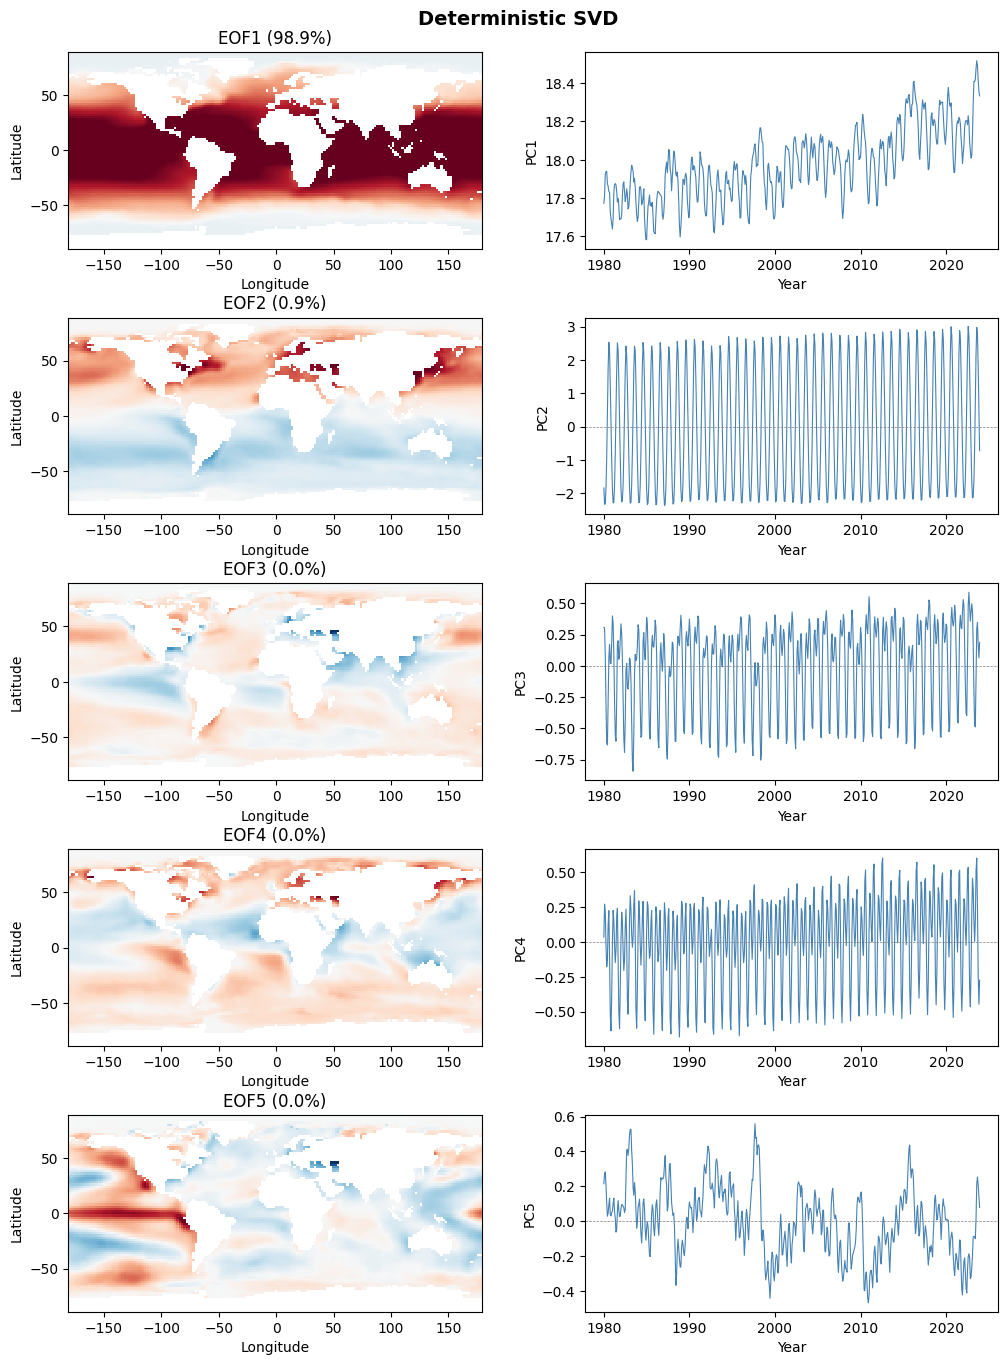

In [7]:
mode_names = ["EOF1", "EOF2", "EOF3", "EOF4", "EOF5"]

fig, axes = plt.subplots(5, 2, figsize=(12, 14))
fig.suptitle("Deterministic SVD", fontsize=14, fontweight='bold')

for i in range(5):
    # Left: Spatial EOF pattern
    ax_spatial = axes[i, 0]
    clim = np.nanmax(np.abs(EOF_maps_det[i])) * 0.8
    im = ax_spatial.pcolormesh(lon, lat, EOF_maps_det[i].T, cmap='RdBu_r',
                                vmin=-clim, vmax=clim, shading='auto')
    ax_spatial.set_xlabel("Longitude")
    ax_spatial.set_ylabel("Latitude")
    ax_spatial.set_title(f"{mode_names[i]} ({100*var_explained[i]:.1f}%)")

    # Right: Temporal PC coefficient
    ax_temporal = axes[i, 1]
    ax_temporal.plot(years, PC_det[i], linewidth=0.8, color='steelblue')
    ax_temporal.set_xlabel("Year")
    ax_temporal.set_ylabel(f"PC{i+1}")
    if i > 0:
        ax_temporal.axhline(0, color='gray', linestyle='--', linewidth=0.5)

fig.subplots_adjust(top=0.95, bottom=0.05, hspace=0.35, wspace=0.25)

## Randomized SVD: EOF Patterns

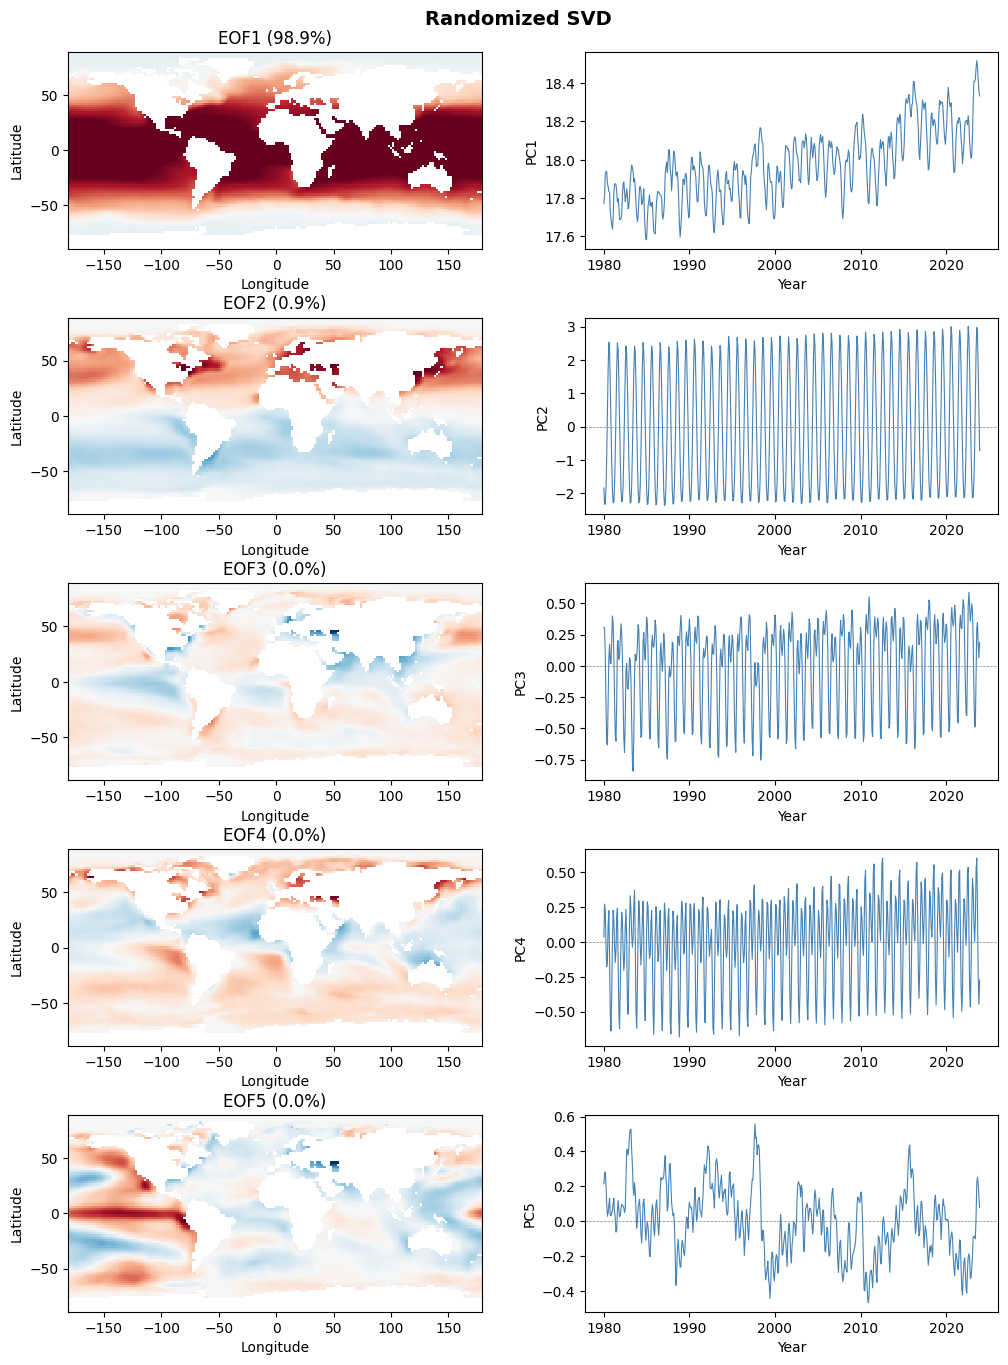

In [8]:
var_explained_rand = s**2 / total_var

fig, axes = plt.subplots(5, 2, figsize=(12, 14))
fig.suptitle("Randomized SVD", fontsize=14, fontweight='bold')

for i in range(5):
    # Left: Spatial EOF pattern
    ax_spatial = axes[i, 0]
    clim = np.nanmax(np.abs(EOF_maps_rand[i])) * 0.8
    im = ax_spatial.pcolormesh(lon, lat, EOF_maps_rand[i].T, cmap='RdBu_r',
                                vmin=-clim, vmax=clim, shading='auto')
    ax_spatial.set_xlabel("Longitude")
    ax_spatial.set_ylabel("Latitude")
    ax_spatial.set_title(f"{mode_names[i]} ({100*var_explained_rand[i]:.1f}%)")

    # Right: Temporal PC coefficient
    ax_temporal = axes[i, 1]
    ax_temporal.plot(years, PC_rand[i], linewidth=0.8, color='steelblue')
    ax_temporal.set_xlabel("Year")
    ax_temporal.set_ylabel(f"PC{i+1}")
    if i > 0:
        ax_temporal.axhline(0, color='gray', linestyle='--', linewidth=0.5)

fig.subplots_adjust(top=0.95, bottom=0.05, hspace=0.35, wspace=0.25)

## Singular Value Spectrum

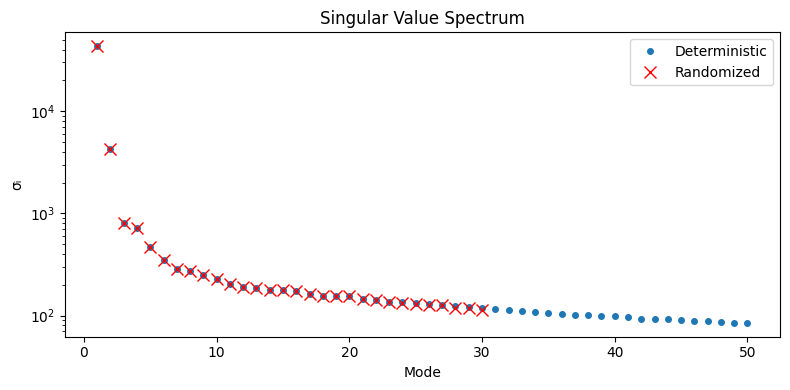

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

n_plot = min(50, len(s_full))
ax.semilogy(range(1, n_plot + 1), s_full[:n_plot],
             'o', markersize=4, label="Deterministic")
ax.semilogy(range(1, n_modes + 1), s, 'x', markersize=8, color='red',
             label="Randomized")
ax.set_xlabel("Mode")
ax.set_ylabel("σᵢ")
ax.set_title("Singular Value Spectrum")
ax.legend()

fig.tight_layout()

## ENSO Analysis

The Niño 3.4 region (5°N-5°S, 170°W-120°W) is used to validate the
ENSO mode (EOF5). Detrending removes the warming trend to reveal the
interannual ENSO signal.

Correlation between PC5 and Niño 3.4 index: 0.642
Correlation (detrended): 0.682


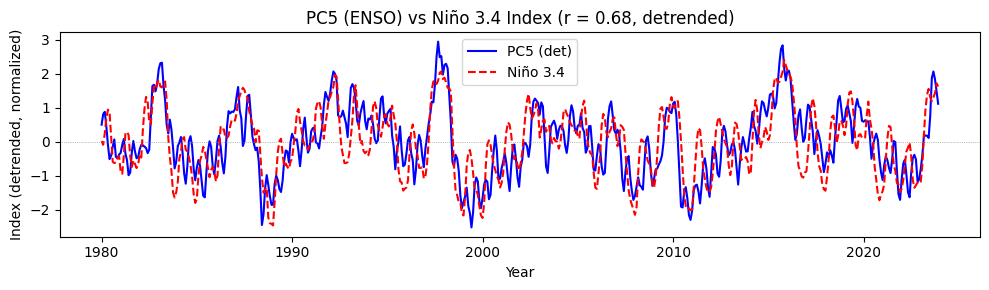

In [10]:
# Correlation without detrending
corr_pc5_nino_raw = pearsonr(PC_det[4], nino34_index)[0]
print(f"Correlation between PC5 and Ni\u00f1o 3.4 index: {corr_pc5_nino_raw:.3f}")

# Detrend to remove warming trend and reveal ENSO signal
pc5_detrend = detrend(PC_det[4])
nino34_detrend = detrend(nino34_index)

corr_pc5_nino = pearsonr(pc5_detrend, nino34_detrend)[0]
print(f"Correlation (detrended): {corr_pc5_nino:.3f}")

# Plot comparison (detrended and normalized)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(years, pc5_detrend / np.std(pc5_detrend), linewidth=1.5, label="PC5 (det)", color='blue')
ax.plot(years, nino34_detrend / np.std(nino34_detrend), linewidth=1.5,
         label="Ni\u00f1o 3.4", color='red', linestyle='--')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Index (detrended, normalized)")
ax.set_title(f"PC5 (ENSO) vs Ni\u00f1o 3.4 Index (r = {corr_pc5_nino:.2f}, detrended)")
ax.legend()

fig.tight_layout()

## Summary

In [11]:
print("Data: NOAA ERSST v5")
print(f"Grid: {n_lon} x {n_lat} (2\u00b0 resolution)")
print(f"Time: {dates[0].strftime('%Y-%m')} to {dates[-1].strftime('%Y-%m')} ({n_time} months)")
print(f"Ocean points: {n_ocean}")
print()
print("EOF Analysis:")
print(f"  EOF1 variance: {100*var_explained[0]:.1f}% (mean pattern)")
print(f"  EOF5 variance: {100*var_explained[4]:.1f}% (ENSO)")
print(f"  Modes for 90% variance: {n90}")
separable = north_test(s_full, n_samples=n_time)
n_well_separated = np.sum(separable[:10])
print(f"  Well-separated modes (North's rule): {n_well_separated}/10")
print()
print("Randomized SVD accuracy:")
rel_err = norm(s - s_full[:n_modes]) / norm(s_full[:n_modes])
print(f"  Singular value error: {100*rel_err:.3f}%")
print()
print("ENSO validation (PC5 - Ni\u00f1o 3.4 correlation):")
pc5_rand_detrend = detrend(PC_rand[4])
corr_pc5_rand_raw = pearsonr(PC_rand[4], nino34_index)[0]
corr_pc5_rand = pearsonr(pc5_rand_detrend, nino34_detrend)[0]
print(f"  Deterministic SVD: {corr_pc5_nino_raw:.3f} (detrended: {corr_pc5_nino:.3f})")
print(f"  Randomized SVD:    {corr_pc5_rand_raw:.3f} (detrended: {corr_pc5_rand:.3f})")

Data: NOAA ERSST v5
Grid: 180 x 89 (2° resolution)
Time: 1980-01 to 2023-12 (528 months)
Ocean points: 10988

EOF Analysis:
  EOF1 variance: 98.9% (mean pattern)
  EOF5 variance: 0.0% (ENSO)
  Modes for 90% variance: 1
  Well-separated modes (North's rule): 10/10

Randomized SVD accuracy:
  Singular value error: 0.018%

ENSO validation (PC5 - Niño 3.4 correlation):
  Deterministic SVD: 0.642 (detrended: 0.682)
  Randomized SVD:    0.642 (detrended: 0.682)
